In [1]:
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
print(tf.config.list_physical_devices('GPU'))

2024-11-07 22:50:44.164734: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-11-07 22:50:44.175615: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-11-07 22:50:44.184960: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-11-07 22:50:44.188265: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-11-07 22:50:44.197867: I tensorflow/core/platform/cpu_feature_guar

Num GPUs Available:  1
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


I0000 00:00:1731037846.273933  165217 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1731037846.312192  165217 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1731037846.312244  165217 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.


In [2]:
import dask.dataframe as dd
import glob
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras import models, layers
from tensorflow.keras.callbacks import EarlyStopping

# Suppress TensorFlow warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

print("1")

# Read multiple CSV files into a Dask DataFrame
file_paths = glob.glob('/mnt/c/Users/aardp/Downloads/OJ/cleaned_csv/R3.0.0/combined/*.csv')
print("2")
dataset = dd.read_csv(file_paths, assume_missing=True)
print("3")

# Load the data
df = dataset
print("4")

# Display the first few rows of the dataframe
# print(df.head())
print("5")
# Display information about the dataframe
# print(df.info())
print("6")
# Check for any remaining NaN values
# print(df.isna().sum().compute())
print("7")
# Remove rows with NaN values (if any)
df = df.dropna()
print("8")
df['Longitude'] = df['Longitude'] + df['S-Mean Longitude']
df['Latitude'] = df['Latitude'] + df['S-Mean Latitude']
df['Longitude'] = df['Longitude'].apply(lambda x: x - 360 if x > 180 else x, meta=('x', 'f8'))
print("9")
# Extract temporal features from 'Year/Month'
df['Year/Month'] = dd.to_datetime(df['Year/Month'], format='%Y/%m')
df['Year'] = df['Year/Month'].dt.year
df['Month'] = df['Year/Month'].dt.month
print("10")
# Drop the original 'Year/Month' column
df = df.drop(columns=['Year/Month'])
print("11")
# Check for any NaN values after pivoting
# print(df.isna().sum().compute())
print("12")
# Handle missing values
df = df.fillna('ffill')
print("13")
# Display statistical summary
# print(df.describe().compute())
print("14")
df = df[df['Longitude'] >= -80]
df = df[df['Longitude'] <= -10]
df = df[df['Latitude'] >= 0]

1
2
3
4
5
6
7
8
9
10
11
12
13
14


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = df.compute()

# Keep Longitude, Latitude, and the variables you are interested in
df_pos = df[['Longitude', 'Latitude']]
df_vars = df[['S-Mean', 'A-Mean', 'Q-Mean', 'R-Mean_x', 
             'W-Mean', 'U-Mean', 'V-Mean', 'P-Mean', 'C-Mean',
             #'X=W*U-Mean', 'Y=W*V-Mean', 
             #'D=S-A-Mean', 'E=(S-A)*W-Mean', 'F=QS-Q-Mean', 'G=(QS-Q)*W-Mean',
             #'I=U*A-Mean', 'J=V*A-Mean', 'K=U*Q-Mean', 'L=V*Q-Mean',
             #'M=(QS-Q)*U-Mean', 'N=(QS-Q)*V-Mean', 
             #'B1=W*W*W-Mean', 'B2=W*W*W-Mean'
             ]]
print("15")

# Step 2: Split the data into training and test sets
X_train_pos, X_test_pos, X_train_vars, X_test_vars, y_train, y_test = train_test_split(
    df_pos, df_vars, df['S-Mean'], test_size=0.2, random_state=42
)
print("16")

# Step 3: Normalize only the variables, not the position
scaler = StandardScaler()
X_train_vars = scaler.fit_transform(X_train_vars)
X_test_vars = scaler.transform(X_test_vars)
print("17")

# Step 4: Combine Longitude, Latitude, and Variables efficiently
def combine_pos_and_vars(X_pos, X_vars):
    # Combine Longitude and Latitude with the variables
    return np.hstack((X_pos.values, X_vars))

# Step 5: Reshape both training and test sets
X_train = combine_pos_and_vars(X_train_pos, X_train_vars)
print("18")
X_test = combine_pos_and_vars(X_test_pos, X_test_vars)
print("19")

In [ ]:
import numpy as np
from tensorflow.keras import models, layers
from tensorflow.keras.callbacks import EarlyStopping

# Define the updated 2D CNN model
n_vars = 9  # Number of variables used in the input

model = models.Sequential([
    layers.Conv2D(200, (4, 4), activation='relu', padding='same', input_shape=(1, n_vars, 1)),  # Adjust input shape
    layers.MaxPooling2D((1, 1), padding='same'),
    layers.Conv2D(200, (1, 1), activation='relu', padding='same'),
    layers.MaxPooling2D((1, 1), padding='same'),
    layers.Conv2D(200, (1, 1), activation='relu', padding='same'),
    layers.MaxPooling2D((1, 1), padding='same'),
    layers.Flatten(),
    layers.Dense(200, activation='relu'),
    layers.Dense(100, activation='relu'),
    layers.Dense(1, activation='linear')  # Predicting a continuous value
])

# Compile the model
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Reshape the input data to match the model's expected input shape
# Extract only the variable columns, skipping longitude and latitude
X_train_vars_only = X_train[:, 2:]  # Keep only the variable columns
X_test_vars_only = X_test[:, 2:]

# Reshape to (samples, 1, n_vars, 1) to fit the CNN input
X_train_reshaped = X_train_vars_only.reshape((-1, 1, n_vars, 1))
X_test_reshaped = X_test_vars_only.reshape((-1, 1, n_vars, 1))

# Model summary
model.summary()

# Train the model with early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=1000, restore_best_weights=True)
history = model.fit(X_train_reshaped, y_train, epochs=1000, validation_split=0.2, callbacks=[early_stopping])

# Evaluate the model on the test set
loss, mae = model.evaluate(X_test_reshaped, y_test)
print(f'Validation/Test MSE/Loss: {loss}')
print(f'Validation/Test MAE: {mae}')

# Make predictions
predictions = model.predict(X_test_reshaped)

In [ ]:
model.save('MeanSST2D_Layer3Test.keras')

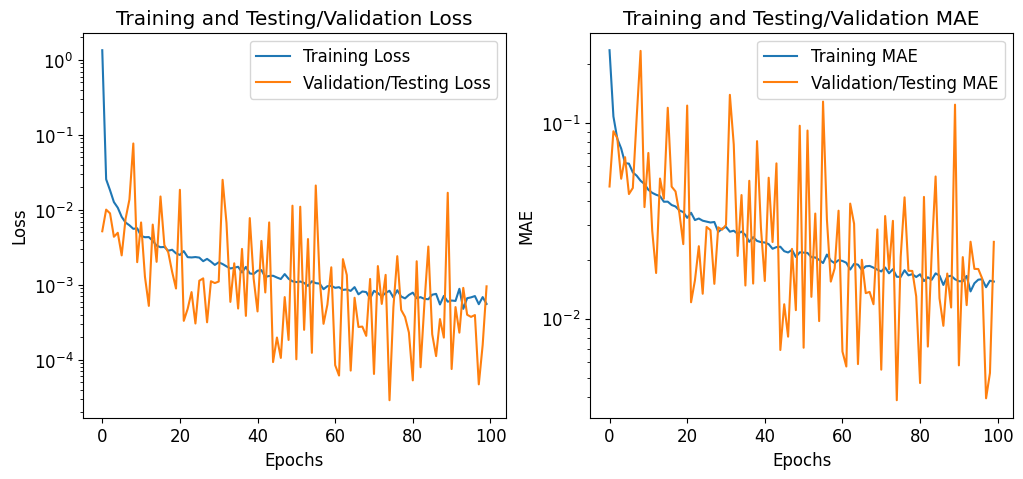

In [8]:
import matplotlib.pyplot as plt

# Plot the training and validation loss and MAE
plt.figure(figsize=(12, 5))
plt.rcParams.update({'font.size': 12})

# Plot loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation/Testing Loss')
plt.title('Training and Testing/Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.yscale('log')  # Set y-axis to logarithmic scale
plt.legend()

# Plot MAE
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation/Testing MAE')
plt.title('Training and Testing/Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.yscale('log')  # Set y-axis to logarithmic scale
plt.legend()

plt.show()

In [1]:
import tensorflow as tf

2024-10-21 22:03:00.467901: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-10-21 22:03:00.638937: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-10-21 22:03:00.698828: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-10-21 22:03:00.716033: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-10-21 22:03:00.840651: I tensorflow/core/platform/cpu_feature_guar

In [2]:
model = tf.keras.models.load_model('MeanSST2D-10-3.keras')
model.summary()

I0000 00:00:1729562583.561922   63878 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1729562583.690344   63878 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1729562583.690395   63878 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1729562583.694917   63878 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1729562583.694959   63878 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:0

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 1, 9, 200)      │         3,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 1, 9, 200)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 1, 9, 200)      │        40,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 1, 9, 200)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1800)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 200)            │       360,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,272,005 (4.85 MB)

 Trainable params: 424,001 (1.62 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 848,004 (3.23 MB)

In [3]:
import os
import pandas as pd
import numpy as np
import csv
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import LinearSegmentedColormap
import tensorflow as tf

# Path to the folder containing CSV files
folder_path = '/mnt/c/Users/aardp/Downloads/OJ/cleaned_csv/R3.0.0/combined/'

# Get list of CSV files in the folder
csv_files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]

# Define custom colormap
def custom_coolwarm():
    coolwarm = plt.cm.coolwarm
    colors = coolwarm(np.linspace(0.1, 1, 256))
    return LinearSegmentedColormap.from_list('custom_coolwarm', colors)

# Function to save predictions to a CSV file
def save_predictions_to_csv(predictions, lons, lats, year, month, folder_path):
    csv_file = os.path.join(folder_path, "MeanSST2D_10-3", f"MeanSST2D_10-3.{year}.{month}.csv")
    with open(csv_file, mode='w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(["Year", "Month", "Longitude", "Latitude", "S-Mean"])
        for lon, lat, pred in zip(lons, lats, predictions):
            writer.writerow([year, month, lon, lat, pred])
    print(f"CSV saved: {csv_file}")

# Function to plot the world map with predicted values
def plot_world_map(variable, title, actualorprediction, dataset_test, file_name):
    plt.figure(figsize=(20, 20))
    plt.rcParams.update({'font.size': 24, 'font.family': 'sans-serif'})
    ax = plt.axes(projection=ccrs.PlateCarree())

    # Add map features
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.add_feature(cfeature.OCEAN, color='lightblue')
    ax.add_feature(cfeature.LAND, color='lightgreen', edgecolor='black')
    ax.add_feature(cfeature.LAKES, edgecolor='black')
    ax.add_feature(cfeature.RIVERS)
    ax.set_extent([-80, -10, 0, 90])

    # Scatter plot of predictions
    scatter = ax.scatter(dataset_test['Longitude'], dataset_test['Latitude'], c=actualorprediction, cmap=custom_cmap,
                         s=300, transform=ccrs.PlateCarree(), vmin=-6, vmax=36)
    
    cbar = plt.colorbar(scatter, label='Mean SST (°C)')
    cbar.set_ticks([-6, -3, 0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 36])
    cbar.set_ticklabels(['-6', '-3', '0', '3', '6', '9', '12', '15', '18', '21', '24', '27', '30', '33', '36'])

    plt.title(f'Predicted Mean SST Distribution - {file_name[-11:-4]}')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.grid(True)
    
    output_file_name = file_name.replace('.csv', '.png')
    output_path = os.path.join(folder_path, 'MeanSST2D_10-3', output_file_name)
    plt.savefig(output_path)
    print(f"Saved {file_name}")
    
    plt.close()

# Load data and perform prediction
for file_name in csv_files:
    dataset_test = pd.read_csv(os.path.join(folder_path, file_name))
    
    # Update the Longitude and Latitude as per your logic
    dataset_test['Longitude'] = dataset_test['Longitude'] + dataset_test['S-Mean Longitude']
    dataset_test['Latitude'] = dataset_test['Latitude'] + dataset_test['S-Mean Latitude']
    dataset_test['Longitude'] = dataset_test['Longitude'].apply(lambda x: x - 360 if x > 180 else x)

    # Extract Year and Month
    dataset_test['Year/Month'] = pd.to_datetime(dataset_test['Year/Month'], format='%Y/%m')
    dataset_test['Year'] = dataset_test['Year/Month'].dt.year
    dataset_test['Month'] = dataset_test['Year/Month'].dt.month
    dataset_test.drop(columns=['Year/Month'], inplace=True)

    X_test_pos = dataset_test[['Longitude', 'Latitude']]
    X_test_vars = dataset_test[['S-Mean', 'A-Mean', 'Q-Mean', 'R-Mean_x', 
                                'W-Mean', 'U-Mean', 'V-Mean', 'P-Mean', 'C-Mean']]
    
    # Normalize variables
    scaler = StandardScaler()
    X_test_vars_scaled = scaler.fit_transform(X_test_vars)
    
    # Reshape to match the model input (samples, 1, n_vars, 1)
    X_test_reshaped = X_test_vars_scaled.reshape((-1, 1, X_test_vars_scaled.shape[1], 1))

    # Convert to TensorFlow tensor for model prediction
    X_test_tf = tf.convert_to_tensor(X_test_reshaped, dtype=tf.float32)

    # Predict
    predictions = model.predict(X_test_tf)
    predicted_sst = predictions.flatten()

    year = dataset_test['Year'].iloc[0]
    month = dataset_test['Month'].iloc[0]
    save_predictions_to_csv(predicted_sst, dataset_test['Longitude'], dataset_test['Latitude'], year, month, folder_path)

    # Plot the predictions
    custom_cmap = custom_coolwarm()
    plot_world_map('S-Mean', 'Predicted S-Mean Values', predicted_sst, dataset_test, file_name)

print("Plots saved successfully.")

I0000 00:00:1729562585.553665   64037 service.cc:146] XLA service 0x7f8d14004940 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1729562585.553728   64037 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce RTX 4090, Compute Capability 8.9
2024-10-21 22:03:05.574983: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2024-10-21 22:03:05.643181: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8907


 80/125 ━━━━━━━━━━━━━━━━━━━━ 0s 640us/step

I0000 00:00:1729562586.761023   64037 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
CSV saved: /mnt/c/Users/aardp/Downloads/OJ/cleaned_csv/R3.0.0/combined/MeanSST2D_10-3/MeanSST2D_10-3.1932.1.csv
Saved MSG2.1932.01.csv
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
CSV saved: /mnt/c/Users/aardp/Downloads/OJ/cleaned_csv/R3.0.0/combined/MeanSST2D_10-3/MeanSST2D_10-3.1932.2.csv
Saved MSG2.1932.02.csv
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
CSV saved: /mnt/c/Users/aardp/Downloads/OJ/cleaned_csv/R3.0.0/combined/MeanSST2D_10-3/MeanSST2D_10-3.1932.3.csv
Saved MSG2.1932.03.csv
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
CSV saved: /mnt/c/Users/aardp/Downloads/OJ/cleaned_csv/R3.0.0/combined/MeanSST2D_10-3/MeanSST2D_10-3.1932.4.csv
Saved MSG2.1932.04.csv
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
CSV saved: /mnt/c/Users/aardp/Downloads/OJ/cleaned_csv/R3.0.0/combined/MeanSST2D_10-3/MeanSST2D_10-3.1932.5.csv
Saved MSG2.1932.05.csv
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
CSV saved: /mnt/c/Users/aardp/Downloads/OJ/cleaned_csv/R3.0.0/combined/MeanSST2

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from scipy.interpolate import griddata
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import LinearSegmentedColormap
from sklearn.preprocessing import StandardScaler

# Path to the folder containing CSV files
folder_path = '/mnt/c/Users/aardp/Downloads/OJ/cleaned_csv/R3.0.0/combined/'

# Get list of CSV files in the folder
csv_files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]

# Define custom colormap
def custom_coolwarm():
    coolwarm = plt.cm.coolwarm
    colors = coolwarm(np.linspace(0.1, 1, 256))
    return LinearSegmentedColormap.from_list('custom_coolwarm', colors)

# Function to plot the world map with predicted values
def plot_world_map(variable, title, actualorprediction, lons, lats):
    plt.figure(figsize=(20, 20))
    plt.rcParams.update({'font.size': 24})
    plt.rcParams.update({'font.family': 'sans-serif'})
    ax = plt.axes(projection=ccrs.PlateCarree())

    # Add map features
    ax.coastlines(zorder=6)
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.add_feature(cfeature.OCEAN, color='lightblue', zorder=2)
    ax.add_feature(cfeature.LAND, color='lightgreen', edgecolor='black', zorder=4)
    ax.add_feature(cfeature.LAKES, edgecolor='black', zorder=6)
    ax.add_feature(cfeature.RIVERS, zorder=5)
    ax.set_extent([-80, -10, 0, 90])

    levels = np.linspace(-6, 37)
    
    # Contour map
    gradient = plt.contourf(lons, lats, actualorprediction, transform=ccrs.PlateCarree(), cmap=custom_coolwarm(), levels=levels, vmin=-6, vmax=36, zorder=3)

    # Contour line
    line_c = ax.contour(lons, lats, actualorprediction, levels=[12], colors='black', transform=ccrs.PlateCarree(), zorder=3)
    ax.clabel(line_c, colors=['black'], inline=True, fmt=' {:.0f} '.format, zorder=2)

    # Adjust color bar
    cbar = plt.colorbar(gradient)
    cbar.set_label('Mean SST (°C)')
    cbar.set_ticks(list(range(-6, 37)))
    cbar.set_ticklabels(['-6', '', '', '-3', '', '', '0', '', '', '3', '', '', '6', '', '', '9', '', '', '12', '', '', '15', '', '', '18', '', '',
                         '21', '', '', '24', '', '', '27', '', '', '30', '', '', '33', '', '', '36'])

    plt.title(f'Predicted Mean SST Distribution - {title}')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.grid(True)
    
    # Save the plot
    output_file_name = file_name.replace('.csv', '.png')
    output_path = os.path.join(folder_path, 'MeanSST2D_10-3_contour_' + output_file_name)
    plt.savefig(output_path)
    print(f"Saved {file_name}")
    
    # Close the plot to release memory
    plt.close()

# Loop through the files
for file_name in csv_files:
    dataset_test = pd.read_csv(os.path.join(folder_path, file_name))
    dataset_test = dataset_test.dropna()

    # Update Longitude and Latitude
    dataset_test['Longitude'] = dataset_test['Longitude'] + dataset_test['S-Mean Longitude']
    dataset_test['Latitude'] = dataset_test['Latitude'] + dataset_test['S-Mean Latitude']
    dataset_test['Longitude'] = dataset_test['Longitude'].apply(lambda x: x - 360 if x > 180 else x)

    # Extract Year and Month
    dataset_test['Year/Month'] = pd.to_datetime(dataset_test['Year/Month'], format='%Y/%m')
    dataset_test['Year'] = dataset_test['Year/Month'].dt.year
    dataset_test['Month'] = dataset_test['Year/Month'].dt.month
    dataset_test.drop(columns=['Year/Month'], inplace=True)

    # Extract variables for prediction (excluding Longitude and Latitude)
    X_test_vars = dataset_test[['S-Mean', 'A-Mean', 'Q-Mean', 'R-Mean_x', 
                                'W-Mean', 'U-Mean', 'V-Mean', 'P-Mean', 'C-Mean']]

    # Normalize the variables
    scaler = StandardScaler()
    X_test_vars_scaled = scaler.fit_transform(X_test_vars)

    # Reshape to match model input (samples, 1, n_vars, 1)
    X_test_reshaped = X_test_vars_scaled.reshape((-1, 1, X_test_vars_scaled.shape[1], 1))

    # Convert to TensorFlow tensor for prediction
    X_test_tf = tf.convert_to_tensor(X_test_reshaped, dtype=tf.float32)

    # Model prediction
    predictions = model.predict(X_test_tf)
    predicted_sst = predictions.flatten()

    # Define grid dimensions for interpolation
    unique_lats = np.sort(dataset_test['Latitude'].unique())
    unique_lons = np.sort(dataset_test['Longitude'].unique())
    lat_grid, lon_grid = np.meshgrid(unique_lats, unique_lons)

    # Interpolate the predicted SST onto a regular grid
    grid_values = griddata(
        (dataset_test['Latitude'], dataset_test['Longitude']),
        predicted_sst,
        (lat_grid, lon_grid),
        method='linear'
    )

    # Plot the predicted values on a world map
    plot_world_map('S-Mean', file_name[-11:-4], grid_values, lon_grid, lat_grid)

print("Plots saved successfully.")

In [23]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import LinearSegmentedColormap
from sklearn.preprocessing import StandardScaler

# Define custom colormap based on coolwarm with more red at the lower end
def custom_coolwarm():
    coolwarm = plt.cm.coolwarm
    colors = coolwarm(np.linspace(0.1, 1, 256))
    return LinearSegmentedColormap.from_list('custom_coolwarm', colors)

# Function to plot the world map with predicted values
def plot_world_map(lons, lats, predictions, title, folder_path):
    plt.figure(figsize=(20, 20))
    plt.rcParams.update({'font.size': 24, 'font.family': 'sans-serif'})
    ax = plt.axes(projection=ccrs.PlateCarree())

    # Add map features
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.add_feature(cfeature.OCEAN, color='lightblue')
    ax.add_feature(cfeature.LAND, color='lightgreen', edgecolor='black')
    ax.add_feature(cfeature.LAKES, edgecolor='black')
    ax.add_feature(cfeature.RIVERS)
    ax.set_extent([-180, 180, -90, 90])

    scatter = ax.scatter(lons, lats, c=predictions, cmap=custom_coolwarm(), 
                         s=10, transform=ccrs.PlateCarree(), vmin=-6, vmax=36)
    cbar = plt.colorbar(scatter, label='Mean SST (°C)')
    cbar.set_ticks([-6, -3, 0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 36])
    cbar.set_ticklabels(['-6', '-3', '0', '3', '6', '9', '12', '15', '18', '21', '24', '27', '30', '33', '36'])
    
    plt.title(f'Predicted Mean SST Distribution - {title}')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.grid(True)
    
    # Save the plot as an image file
    output_file_name = title + '.png'
    output_path = os.path.join(folder_path, output_file_name)
    plt.savefig(output_path)
    print(f"Saved {output_file_name}")
    
    plt.close()

# Generate a grid of longitude and latitude values covering the entire Earth
lon_grid = np.arange(-180, 181, 1)
lat_grid = np.arange(-90, 91, 1)
lon, lat = np.meshgrid(lon_grid, lat_grid)

# Flatten the grids to create input for the model
lon_flat = lon.flatten()
lat_flat = lat.flatten()

# Path to save the plots
folder_path = '/mnt/c/Users/aardp/Downloads/OJ/cleaned_csv/R3.0.2/combined/'

# Normalize the input data
scaler = StandardScaler()

for year in range(2024, 2050):
    for month in range(1, 13):
        # Prepare input features for prediction
        X_test = pd.DataFrame({
            'Year': year,
            'Month': month,
            'Longitude': lon_flat,
            'Latitude': lat_flat
        })

        # Normalize the input data
        X_test_scaled = scaler.fit_transform(X_test)
        n_features = X_test_scaled.shape[1]
        
        # Assuming the model expects input in the shape (batch_size, height, width, channels)
        X_test_scaled = X_test_scaled.reshape((X_test_scaled.shape[0], 2, n_features // 2, 1))

        # Convert to TensorFlow tensor
        X_test_tf = tf.convert_to_tensor(X_test_scaled, dtype=tf.float32)

        # Make predictions
        predictions = model.predict(X_test_tf)
        predicted_sst = predictions.flatten()

        # Plot the predicted values
        plot_world_map(lon_flat, lat_flat, predicted_sst, f'Predicted S-Mean for {year}-{month:02d}', folder_path)

print("Plots saved successfully.")

2042/2042 ━━━━━━━━━━━━━━━━━━━━ 2s 891us/step
Saved Predicted S-Mean for 2024-01.png
2042/2042 ━━━━━━━━━━━━━━━━━━━━ 2s 913us/step
Saved Predicted S-Mean for 2024-02.png
2042/2042 ━━━━━━━━━━━━━━━━━━━━ 2s 872us/step
Saved Predicted S-Mean for 2024-03.png
2042/2042 ━━━━━━━━━━━━━━━━━━━━ 2s 888us/step
Saved Predicted S-Mean for 2024-04.png
2042/2042 ━━━━━━━━━━━━━━━━━━━━ 2s 813us/step
Saved Predicted S-Mean for 2024-05.png
2042/2042 ━━━━━━━━━━━━━━━━━━━━ 2s 871us/step
Saved Predicted S-Mean for 2024-06.png
2042/2042 ━━━━━━━━━━━━━━━━━━━━ 2s 892us/step
Saved Predicted S-Mean for 2024-07.png
2042/2042 ━━━━━━━━━━━━━━━━━━━━ 2s 949us/step
Saved Predicted S-Mean for 2024-08.png
2042/2042 ━━━━━━━━━━━━━━━━━━━━ 2s 839us/step
Saved Predicted S-Mean for 2024-09.png
2042/2042 ━━━━━━━━━━━━━━━━━━━━ 2s 905us/step
Saved Predicted S-Mean for 2024-10.png
2042/2042 ━━━━━━━━━━━━━━━━━━━━ 2s 878us/step
Saved Predicted S-Mean for 2024-11.png
2042/2042 ━━━━━━━━━━━━━━━━━━━━ 2s 759us/step
Saved Predicted S-Mean for 2024

KeyboardInterrupt: 